Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
%%capture
!pip install watermark
!pip install torchinfo datasets pytorch-crf
!pip install -U datasets

In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch,datasets

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch   : 2.9.0+cu126
datasets: 4.8.3



# Bidirectional LSTM + CRF for Named Entity Recognition (NER)

This notebook implements a robust **Token Classification** architecture. Unlike Seq2Seq, which generates a new sequence, NER assigns a specific label to every token in the input. We utilize a **Bidirectional LSTM** to capture context from both directions and a **Conditional Random Field (CRF)** layer to ensure logical label sequences (e.g., preventing an `I-PER` from following a `B-LOC`).


**Network Architecture:**
1. **The Embedding Layer:** Converts tokens into dense vectors.
2. **The Bi-LSTM:** Processes the sentence forward and backward, concatenating the results to understand if "Apple" is a fruit or a company based on surrounding words.
3. **The CRF Layer:** Models the dependencies between output tags, enforcing the IOB (Inside, Outside, Beginning) schema.

---
### **Key Concepts of NER Architecture:**
1. **Token-Level Prediction:** The input length exactly matches the output length ($N \to N$).
2. **IOB Tagging:** Handles multi-word entities (e.g., "New" = `B-LOC`, "York" = `I-LOC`).
3. **Context Windows:** Using Bi-LSTMs allows the model to "see the future" of the sentence to better classify the current word.
4. **Transition Matrices:** The CRF learns which tag transitions are likely (e.g., `B-PER` $\to$ `I-PER`) and which are impossible.

---
### The Conditional Random Field (CRF) Layer

The CRF layer sits on top of our Bi-LSTM emissions (logits). It maintains a learned **Transition Matrix** of size `[NUM_TAGS, NUM_TAGS]`. 

For example, if we have tags `[O, B-PER, I-PER, B-LOC]`, the CRF learns transition scores like:
| From \ To | O | B-PER | I-PER | B-LOC |
| :--- | :--- | :--- | :--- | :--- |
| **O** | High | High | **-1000 (Invalid)** | High |
| **B-PER** | High | Low | **High (Valid)** | Low |

Instead of `CrossEntropyLoss`, the CRF computes the **Negative Log-Likelihood** of the entire sequence of tags. During inference, it uses **Viterbi Decoding** to find the globally optimal path through the transition matrix.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Sampler, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, DatasetDict
from collections import Counter

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary
from torchcrf import CRF


import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [5]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128
LEARNING_RATE = 0.0005    # 0.001
NUM_EPOCHS = 10          # News topics usually converge faster than char-level text
# NUM_CLASSES = 4        # [World, Sports, Business, Sci/Tech]

# Vocabulary & Architecture
VOCABULARY_SIZE = 20000 
EMBEDDING_DIM = 128
HIDDEN_DIM = 128 #256
DROPOUT_P = 0.5        # Crucial for Stacked architectures to prevent overfitting

# Sequence Constraints
# MAX_LEN = 100          # AG News sentences are shorter than Wikipedia/Shakespeare chunks
# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


---
# 1. Data Preparation & Loading

---

In [6]:
# 1. Load CoNLL2003 NER Dataset
raw_datasets = load_dataset("lhoestq/conll2003")

# 2. Extract Tag Mappings
# CoNLL2003 has 9 standard tags (O, B-PER, I-PER, B-ORG, I-ORG, B-LOC, I-LOC, B-MISC, I-MISC)
tag_names = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC", "B-MISC", "I-MISC"]
# tag_names = raw_datasets["train"].features["ner_tags"].feature.names
NUM_TAGS = len(tag_names)
tag2idx = {tag: i for i, tag in enumerate(tag_names)}
idx2tag = {i: tag for tag, i in tag2idx.items()}

print(f"Dataset Loaded . Number of Tags: {NUM_TAGS}")
print(f"Tags: {tag_names}")
print(f"Mapping Check: {tag2idx['B-PER']} -> B-PER")

# 3. Build Word Vocabulary
# Note: Lowercasing is standard for basic NER to reduce vocab size
word_counts = Counter()
for tokens in raw_datasets['train']['tokens']:
    word_counts.update([t.lower() for t in tokens])

VOCABULARY_SIZE = 20000
vocab = {'<PAD>': 0, '<UNK>': 1}
for i, (word, _) in enumerate(word_counts.most_common(VOCABULARY_SIZE - 2)):
    vocab[word] = i + 2

print(f"Vocabulary Size: {len(vocab)}")

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Dataset Loaded . Number of Tags: 9
Tags: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
Mapping Check: 1 -> B-PER
Vocabulary Size: 20000


In [7]:
# Pick a random sample and check if the tags make sense
sample = raw_datasets["train"][4] # Usually a sentence about "Germany" or "European Commission"
print("Tokens:", sample["tokens"])
print("Tags:  ", [idx2tag[t] for t in sample["ner_tags"]])

Tokens: ['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
Tags:   ['B-LOC', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [8]:
class NERTexDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_split):
        self.data = dataset_split
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        # Tokens are strings, ner_tags are already integers (0-8)
        return self.data[idx]['tokens'], self.data[idx]['ner_tags']

class BucketSampler(Sampler):
    def __init__(self, data_source, batch_size, shuffle=True):
        self.data_source = data_source
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = sorted(range(len(data_source)), key=lambda i: len(data_source[i][0]))

    def __iter__(self):
        batches = [self.indices[i:i + self.batch_size] for i in range(0, len(self.indices), self.batch_size)]
        if self.shuffle:
            random.shuffle(batches)
        return iter([idx for batch in batches for idx in batch])

    def __len__(self):
        return len(self.data_source)

def ner_collate_fn(batch):
    text_list, label_list, lengths = [], [], []

    for _text, _label in batch:
        # Numericalize text using your 'vocab' dictionary
        processed_text = torch.tensor([vocab.get(t.lower(), vocab['<UNK>']) for t in _text], dtype=torch.long)
        text_list.append(processed_text)
        
        # Labels are already ints, just convert to tensor
        label_list.append(torch.tensor(_label, dtype=torch.long))
        lengths.append(processed_text.size(0))

    # Pad text with 0 (PAD_IDX)
    text_padded = pad_sequence(text_list, batch_first=True, padding_value=0)
    
    # Pad labels with -100 so CrossEntropyLoss (or your accuracy calc) ignores them
    label_padded = pad_sequence(label_list, batch_first=True, padding_value=-100)
    
    return text_padded.to(DEVICE), label_padded.to(DEVICE), torch.tensor(lengths)

# Initialize
train_ds = NERTexDataset(raw_datasets['train'])
val_ds   = NERTexDataset(raw_datasets['validation'])
test_ds = NERTexDataset(raw_datasets['test'])

# Using your BucketSampler for efficiency
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, 
                          sampler=BucketSampler(train_ds, BATCH_SIZE), 
                          collate_fn=ner_collate_fn)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, 
                        collate_fn=ner_collate_fn)

test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, 
                          collate_fn=ner_collate_fn)

---
# 2. Model Creation

---


In [9]:
class RobustBiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_tags, pad_idx=0, dropout_p=0.5):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers=2, 
                            bidirectional=True, batch_first=True, dropout=dropout_p)
        self.dropout = nn.Dropout(dropout_p)
        self.hidden2emissions = nn.Linear(hidden_size * 2, num_tags)
        self.crf = CRF(num_tags, batch_first=True)

    def forward(self, x, lengths, labels=None):
        # 1. Standard Bi-LSTM Pass
        embedded = self.dropout(self.embedding(x))
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_output, _ = self.lstm(packed_embedded)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        # 2. Get Emissions (Raw Logits)
        emissions = self.hidden2emissions(self.dropout(lstm_out))
        
        # 3. Create boolean mask (True for real tokens, False for padding)
        mask = (x != self.pad_idx)

        # 4. CRF Logic
        if labels is not None:
            # FIX: Clone and Replace -100 with 0 to prevent CUDA Assert Error
            # The mask ensures these '0' labels don't affect the gradient
            clean_labels = labels.clone()
            clean_labels[clean_labels == -100] = 0
            
            # CRF returns Log-Likelihood; we negate it for Loss
            loss = -self.crf(emissions, tags=clean_labels, mask=mask, reduction='mean')
            return loss
        else:
            # Viterbi Decode for Inference
            return self.crf.decode(emissions, mask=mask)

In [10]:
set_all_seeds(RANDOM_SEED)

# Initialize the upgraded model
model_crf = RobustBiLSTM_CRF(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, NUM_TAGS, pad_idx=vocab['<PAD>']).to(DEVICE)

In [11]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Safely get components
    embedding_params = sum(p.numel() for p in model.embedding.parameters())
    lstm_params = sum(p.numel() for p in model.lstm.parameters())
    crf_params = sum(p.numel() for p in model.crf.parameters())
    
    # Try to find the linear layer under common names
    linear_layer = None
    for name in ['classifier', 'fc', 'hidden2emissions', 'hidden2tag']:
        if hasattr(model, name):
            linear_layer = getattr(model, name)
            break
            
    linear_params = sum(p.numel() for p in linear_layer.parameters()) if linear_layer else 0
    
    print(f"{'Component':<15} | {'Parameters':<12}")
    print("-" * 30)
    print(f"{'Embedding':<15} | {embedding_params:,}")
    print(f"{'Bi-LSTM':<15} | {lstm_params:,}")
    print(f"{'Linear Layer':<15} | {linear_params:,}")
    print(f"{'CRF Layer':<15} | {crf_params:,}")
    print("-" * 30)
    print(f"{'TOTAL':<15} | {total_params:,}")


count_parameters(model_crf)

Component       | Parameters  
------------------------------
Embedding       | 2,560,000
Bi-LSTM         | 659,456
Linear Layer    | 2,313
CRF Layer       | 99
------------------------------
TOTAL           | 3,221,868


---
# 3. Model Training, Testing & Evaluation

---

In [12]:
def evaluate_ner(model, data_loader, device, tag_names=None, plot=False, hide_outside=False):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for inputs, labels, lengths in data_loader:
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
            
            # 1. Inference: Get Viterbi paths (list of lists)
            batch_preds = model(inputs, lengths)
            
            # 2. Loss: Get Negative Log Likelihood
            loss = model(inputs, lengths, labels=labels)
            total_loss += loss.item() * inputs.size(0)
            
            # 3. Masking: Extract only real tokens (ignore padding -100)
            for i in range(inputs.size(0)):
                seq_len = lengths[i].item()
                real_labels = labels[i, :seq_len].cpu().numpy().tolist()
                
                all_preds.extend(batch_preds[i])
                all_labels.extend(real_labels)

    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    if plot:
        print(f"Loss: {avg_loss:.4f} | Accuracy: {acc:.2%} | Macro F1: {f1:.2%}")
        
        if tag_names:
            # Logic to filter out 'O' tag from the report and plot
            report_labels = list(range(len(tag_names)))
            report_targets = tag_names
            
            if hide_outside:
                # Assuming 'O' is at index 0 (standard for CoNLL)
                o_idx = tag_names.index("O")
                report_labels = [i for i in report_labels if i != o_idx]
                report_targets = [t for i, t in enumerate(tag_names) if i != o_idx]
            
            print(f"\nClassification Report (Hide Outside={hide_outside}):\n")
            print(classification_report(all_labels, all_preds, 
                                        labels=report_labels, 
                                        target_names=report_targets))
            
            # Confusion Matrix
            cm = confusion_matrix(all_labels, all_preds, labels=report_labels)
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=report_targets, yticklabels=report_targets)
            plt.title(f'NER Confusion Matrix (Excluding Outside: {hide_outside})')
            plt.show()

    return avg_loss, acc, f1

In [13]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs, device, 
              tag_names=None, patience=5):
    
    # --- 1. PERFORMANCE & EARLY STOPPING INIT ---
    scaler = torch.amp.GradScaler('cuda')
    start_time = time.time()
    best_val_f1 = 0.0
    epochs_no_improve = 0 
    
    history = {
        'train_loss': [], 'val_loss': [], 
        'val_acc': [], 'val_f1': [], 'lrs': []
    }

    print(f"Starting NER training on {device} (Patience: {patience})...")

    for epoch in range(num_epochs):
        # --- 2. TRAINING PHASE ---
        model.train()
        train_running_loss = 0.0
        train_total_samples = 0

        for inputs, labels, lengths in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            lengths = lengths.to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                # In our RobustBiLSTM_CRF, passing labels returns the loss directly
                loss = model(inputs, lengths, labels=labels)

            scaler.scale(loss).backward()
            
            # Gradient clipping is CRITICAL for Bi-LSTMs to prevent "Exploding Gradients"
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()

            train_running_loss += loss.item() * inputs.size(0)
            train_total_samples += inputs.size(0)

        # --- 3. VALIDATION PHASE ---
        epoch_train_loss = train_running_loss / train_total_samples
        
        # We use the specialized evaluate_ner function we built earlier
        epoch_val_loss, epoch_val_acc, epoch_val_f1 = evaluate_ner(
            model, val_loader, device, tag_names=tag_names, plot=False
        )

        # --- 4. EARLY STOPPING & CHECKPOINT LOGIC ---
        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1
            torch.save(model.state_dict(), 'best_ner_model.pth')
            epochs_no_improve = 0
            status_msg = " * (Saved Best)"
        else:
            epochs_no_improve += 1
            status_msg = f" (No improve: {epochs_no_improve}/{patience})"

        # --- 5. LOGGING ---
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['val_f1'].append(epoch_val_f1)
        history['lrs'].append(current_lr)

        print(f'Epoch {epoch + 1:03d}/{num_epochs:03d} | '
              f'Val Acc: {epoch_val_acc:.2%} | '
              f'Val F1: {epoch_val_f1:.2%} | '
              f'Loss (T/V): {epoch_train_loss:.4f} / {epoch_val_loss:.4f} | '
              f'LR: {current_lr:.6f}{status_msg}')

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch + 1} epochs.")
            break

    total_time = (time.time() - start_time) / 60
    print(f'\nDone! Total Time: {total_time:.2f} min | Best Val F1: {best_val_f1:.2%}')
    
    # Reload the best weights for testing
    model.load_state_dict(torch.load('best_ner_model.pth'))
    return history

In [17]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Check for all possible metrics
    has_acc = 'val_acc' in history
    has_f1  = 'val_f1' in history
    has_gen = 'val_ppl' in history
    
    # Universal plots: Loss + Learning Rate = 2
    num_plots = 2 + int(has_acc) + int(has_f1) + int(has_gen)
    plt.figure(figsize=(num_plots * 5, 5))

    # --- Plot 1: Loss (Universal) ---
    plt.subplot(1, num_plots, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4')
    plt.plot(epochs, history['val_loss'], 's--', label='Val Loss', color='#ff7f0e')
    plt.title('Cross Entropy Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plot_idx = 2

    # --- Plot 2: Accuracy (%) ---
    if has_acc:
        plt.subplot(1, num_plots, plot_idx)
        # plt.plot(epochs, np.array(history['train_acc']) * 100, 'o-', label='Train Acc', color='#1f77b4')
        plt.plot(epochs, np.array(history['val_acc']) * 100, 's--', label='Val Acc', color='#ff7f0e')
        plt.title('Accuracy (%)')
        plt.xlabel('Epochs')
        plt.ylabel('Percentage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 3: F1 Score (%) ---
    if has_f1:
        plt.subplot(1, num_plots, plot_idx)
        plt.plot(epochs, np.array(history['val_f1']) * 100, 'd-', label='Val F1', color='#2ca02c')
        plt.title('F1 Score (%)')
        plt.xlabel('Epochs')
        plt.ylabel('Percentage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 4: Generative Metrics (Dual Axis) ---
    if has_gen:
        plt.subplot(1, num_plots, plot_idx)
        ax1 = plt.gca()
        
        # Perplexity (Purple)
        ax1.plot(epochs, history['val_ppl'], 'o-', label='PPL', color='purple')
        ax1.set_ylabel('Perplexity', color='purple', fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='purple')
        
        if 'val_bpc' in history:
            ax2 = ax1.twinx()
            # BPC (Red)
            ax2.plot(epochs, history['val_bpc'], 'x--', label='BPC', color='red')
            ax2.set_ylabel('Bits Per Character', color='red', fontweight='bold')
            ax2.tick_params(axis='y', labelcolor='red')
            ax2.grid(False) 
            
        plt.title('Generative Metrics')
        ax1.set_xlabel('Epochs')
        ax1.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 5: Learning Rate (Universal) ---
    plt.subplot(1, num_plots, num_plots)
    plt.plot(epochs, history['lrs'], label='LR', color='black', linewidth=2)
    plt.title('LR Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('Rate')
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [15]:
# 1. Setup
optimizer = optim.Adam(model_crf.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# 2. Train
NUM_EPOCHS = 50
history = train_model(model_crf, train_loader, 
                      val_loader, optimizer, 
                      scheduler, NUM_EPOCHS, 
                      DEVICE, tag_names, 
                      patience=12)

Starting NER training on cuda (Patience: 12)...
Epoch 001/050 | Val Acc: 83.25% | Val F1: 10.31% | Loss (T/V): 14.3792 / 10.9900 | LR: 0.000488 * (Saved Best)
Epoch 002/050 | Val Acc: 85.11% | Val F1: 25.18% | Loss (T/V): 9.4237 / 8.9389 | LR: 0.000452 * (Saved Best)
Epoch 003/050 | Val Acc: 86.22% | Val F1: 29.69% | Loss (T/V): 8.1451 / 7.5907 | LR: 0.000397 * (Saved Best)
Epoch 004/050 | Val Acc: 87.28% | Val F1: 35.84% | Loss (T/V): 7.3317 / 6.8237 | LR: 0.000327 * (Saved Best)
Epoch 005/050 | Val Acc: 88.01% | Val F1: 43.28% | Loss (T/V): 6.7853 / 6.3464 | LR: 0.000250 * (Saved Best)
Epoch 006/050 | Val Acc: 88.76% | Val F1: 50.21% | Loss (T/V): 6.4202 / 6.0276 | LR: 0.000173 * (Saved Best)
Epoch 007/050 | Val Acc: 89.07% | Val F1: 51.55% | Loss (T/V): 6.2027 / 5.7792 | LR: 0.000103 * (Saved Best)
Epoch 008/050 | Val Acc: 89.09% | Val F1: 52.42% | Loss (T/V): 6.0238 / 5.7317 | LR: 0.000048 * (Saved Best)
Epoch 009/050 | Val Acc: 89.15% | Val F1: 52.77% | Loss (T/V): 5.9529 / 5.6781

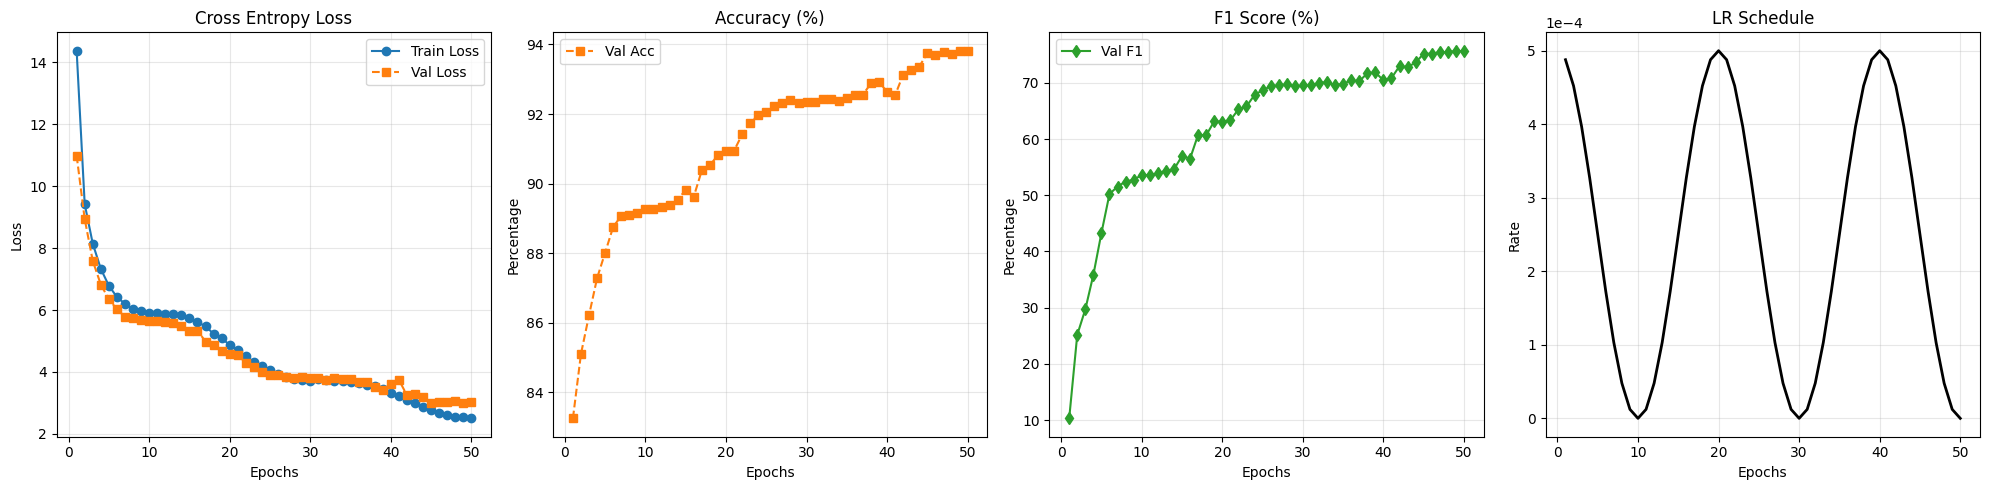

In [18]:
# Visualize & Audit
plot_history(history)


             FINAL TEST SET AUDIT              
Loss: 3.2209 | Accuracy: 92.13% | Macro F1: 69.77%

Classification Report (Hide Outside=False):

              precision    recall  f1-score   support

           O       0.93      0.99      0.96     38323
       B-PER       0.85      0.61      0.71      1617
       I-PER       0.87      0.66      0.75      1156
       B-ORG       0.84      0.54      0.66      1661
       I-ORG       0.74      0.54      0.62       835
       B-LOC       0.90      0.69      0.78      1668
       I-LOC       0.75      0.51      0.61       257
      B-MISC       0.80      0.53      0.64       702
      I-MISC       0.66      0.49      0.56       216

    accuracy                           0.92     46435
   macro avg       0.81      0.62      0.70     46435
weighted avg       0.92      0.92      0.91     46435



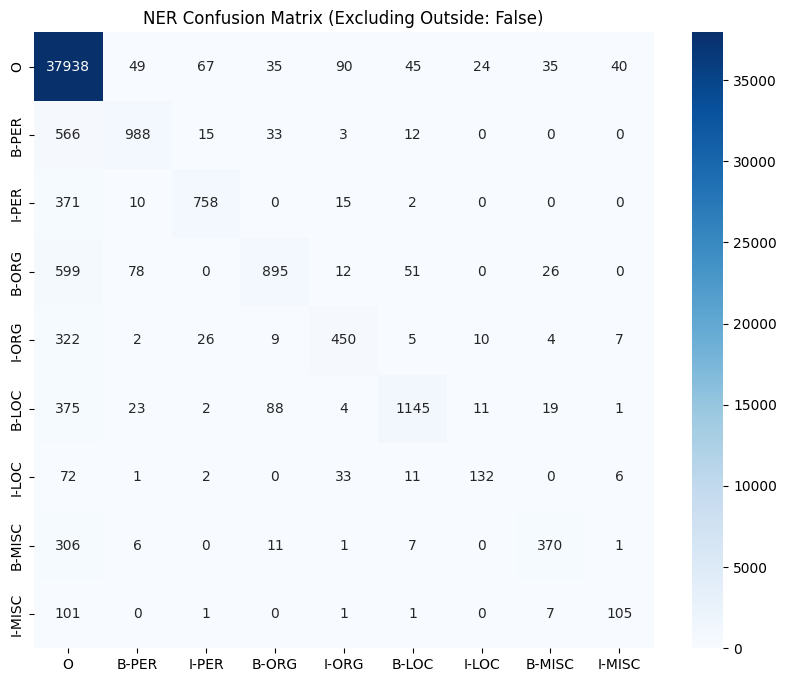


Final Summary | Loss: 3.2209 | Accuracy: 92.13% | F1-score: 69.77%


In [23]:
# --- Final Evaluation (The "Audit") ---
print("\n" + "="*50)
print("             FINAL TEST SET AUDIT              ")
print("="*50)

# We set plot=True here to get the Heatmap and Classification Report
test_loss, test_acc, test_f1 = evaluate_ner(model_crf, test_loader, device=DEVICE, tag_names=tag_names, plot=True, hide_outside=False)

print("="*100)
print(f'\nFinal Summary | Loss: {test_loss:.4f} | Accuracy: {test_acc:.2%} | F1-score: {test_f1:.2%}')
print("="*100)

---
## 4. Model Inference and Sentiment Prediction

---

In [34]:
def predict_ner(model, sentence, vocab, tokenizer, tag_names):
    model.eval()

    # 1. Tokenize (Keeping the original tokens for the final display)
    tokens = tokenizer(sentence)
    
    # 2. Numericalize (Using .get(t, 1) for <UNK> index)
    # Most BERT/Standard tokenizers use lowercase for vocab mapping
    indexed = [vocab.get(t.lower(), 1) for t in tokens]
    
    if len(indexed) == 0:
        return []

    # 3. Prepare Tensors
    tensor = torch.LongTensor(indexed).unsqueeze(0).to(DEVICE)
    length = torch.LongTensor([len(indexed)]).to(DEVICE)

    with torch.no_grad():
        # The CRF model returns a list of lists (best Viterbi paths)
        # We take the first (and only) element in the batch
        prediction_indices = model(tensor, length)[0]

    # 4. Map indices back to tag names
    predicted_tags = [tag_names[idx] for idx in prediction_indices]
    
    # Pair tokens with their tags
    return list(zip(tokens, predicted_tags))

# ================================================================================
def run_ner_test_suite(model, tests, vocab, tokenizer, tag_names):
    """
    Runs NER tests and prints a clearly aligned word-tag report.
    """
    for text in tests:
        print(f"\nSentence: {text}")
        results = predict_ner(model, text, vocab, tokenizer, tag_names)
        
        # Filtering out 'O' (Outside) tags for a cleaner "Insight" report
        entities = [(word, tag) for word, tag in results if tag != 'O']
        
        # Display Logic
        if entities:
            print(f"{'Token':<15} | {'Entity Tag':<10}")
            print("-" * 30)
            for word, tag in entities:
                print(f"{word:<15} | {tag:<10}")
        else:
            print("No entities detected.")
        print("-" * 50)

In [35]:
# Simple robust tokenizer that splits on spaces and punctuation
def tokenizer(text):
    # This regex pulls words and punctuation out as individual tokens
    return re.findall(r"[\w']+|[.,!?;-]", text)

# Now your test suite will run correctly
test_sentences = [
    "Manchester United will play Tottenham in London this Saturday.",
    "The European Commission met in Brussels to discuss the economy.",
    "Elon Musk announced a new project in California."
]

run_ner_test_suite(model_crf, test_sentences, vocab, tokenizer, tag_names)


Sentence: Manchester United will play Tottenham in London this Saturday.
Token           | Entity Tag
------------------------------
Manchester      | B-ORG     
United          | I-ORG     
London          | B-LOC     
--------------------------------------------------

Sentence: The European Commission met in Brussels to discuss the economy.
Token           | Entity Tag
------------------------------
European        | B-ORG     
Commission      | I-ORG     
Brussels        | B-LOC     
--------------------------------------------------

Sentence: Elon Musk announced a new project in California.
Token           | Entity Tag
------------------------------
California      | B-LOC     
--------------------------------------------------


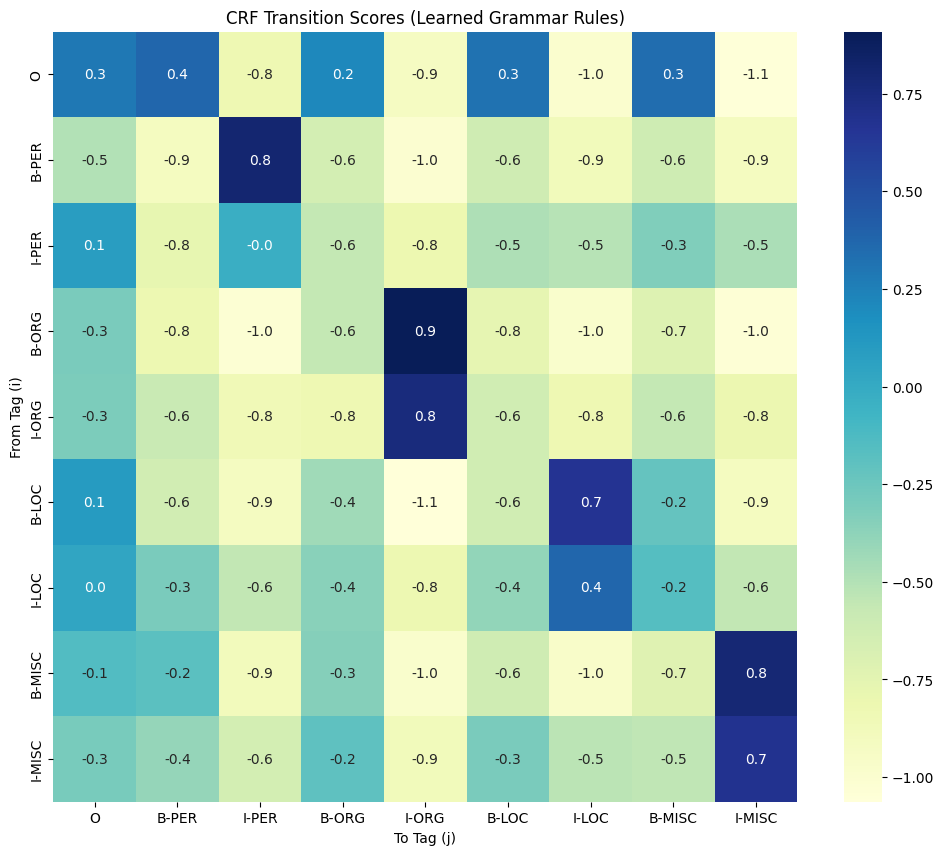

In [36]:
def plot_crf_transitions(model, idx2tag):
    """
    Plots the learned transition matrix of the CRF layer.
    """
    # Extract the transition matrix [num_tags, num_tags]
    # transitions[i, j] is the score of transitioning FROM tag i TO tag j
    transitions = model.crf.transitions.detach().cpu().numpy()
    
    tag_names = [idx2tag[i] for i in range(len(idx2tag))]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(transitions, annot=True, fmt=".1f", cmap="YlGnBu",
                xticklabels=tag_names, yticklabels=tag_names)
    
    plt.title("CRF Transition Scores (Learned Grammar Rules)")
    plt.xlabel("To Tag (j)")
    plt.ylabel("From Tag (i)")
    plt.show()

# RUN THE VISUALIZATION
plot_crf_transitions(model_crf, idx2tag)

In [37]:
def _predict_ner(model, sentence, vocab, idx2tag, device):
    model.eval()
    tokens = sentence.split()
    # Numericalize and add batch dimension
    numericalized = [vocab.get(t.lower(), vocab['<UNK>']) for t in tokens]
    input_tensor = torch.LongTensor(numericalized).unsqueeze(0).to(device)
    lengths = torch.LongTensor([len(numericalized)])
    
    with torch.no_grad():
        # CRF Decode returns a list of lists (Viterbi path)
        paths = model(input_tensor, lengths)
    
    prediction = [idx2tag[idx] for idx in paths[0]]
    
    print(f"{'Word':<15} | {'Tag':<10}")
    print("-" * 30)
    for word, tag in zip(tokens, prediction):
        print(f"{word:<15} | {tag:<10}")

# TEST IT
test_sentence = "Elon Musk and Chizoba are working at Google in London"
_predict_ner(model_crf, test_sentence, vocab, idx2tag, DEVICE)

Word            | Tag       
------------------------------
Elon            | O         
Musk            | O         
and             | O         
Chizoba         | O         
are             | O         
working         | O         
at              | O         
Google          | O         
in              | O         
London          | B-LOC     


In [38]:
%watermark -iv

datasets   : 4.8.3
matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.3.3
re         : 2.2.1
seaborn    : 0.13.2
sklearn    : 1.6.1
torch      : 2.9.0+cu126
torchcrf   : 0.7.2
torchinfo  : 1.8.0
torchvision: 0.24.0+cu126

